# Sentiment Analysis on Product Reviews

We analyse customer review text from an e-commerce dataset.
Each review is classified as **good**, **neutral**, or **bad**.
We use two models: **Logistic Regression** (via Spark MLlib) and **BERT** (via HuggingFace).
All heavy data work runs on Spark with distributed processing.

## Section 0 — Setup

Import all the libraries we need and start a Spark session.
Spark runs locally using all available CPU cores (`local[*]`).

In [2]:
# standard python libraries
import os
import warnings
warnings.filterwarnings('ignore')

# spark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType

# spark ml
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# huggingface bert
from transformers import pipeline as hf_pipeline

# sklearn for extra metrics
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# charting
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

print('All imports OK')

All imports OK


In [3]:
# start spark — local[*] uses all CPU cores as workers
spark = (
    SparkSession.builder
    .appName('SentimentAnalysis')
    .master('local[*]')
    .config('spark.driver.memory', '4g')
    .config('spark.sql.shuffle.partitions', '8')
    .getOrCreate()
)

# suppress noisy spark logs
spark.sparkContext.setLogLevel('ERROR')

print('Spark version:', spark.version)
print('Cores available:', spark.sparkContext.defaultParallelism)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/14 20:23:03 WARN Utils: Your hostname, saag, resolves to a loopback address: 127.0.1.1; using 192.168.0.102 instead (on interface wlp1s0)
26/04/14 20:23:03 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/14 20:23:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1
Cores available: 6


In [4]:
# base path to cleaned dataset folder
BASE = '/home/saag/Documents/BigDataCW/cleaned_dataset'

print('Data folder:', BASE)

Data folder: /home/saag/Documents/BigDataCW/cleaned_dataset


> **Note on BERT and Spark:** BERT (a deep learning model) runs on the **driver** side using a small sample of 2 000 rows.
> This is the standard pragmatic approach — HuggingFace transformers are not natively distributed across Spark workers.
> Logistic Regression runs fully distributed across all workers.

---
## Section 1 — Load Data

We load five CSV tables.
Spark reads each file as a distributed DataFrame — the data is split across partitions automatically.
We then add a `sentiment_label` column based on the star rating.

In [5]:
# load reviews
reviews_df = spark.read.csv(BASE + '/reviews_cleaned.csv', header=True, inferSchema=True)
reviews_df.printSchema()

root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- review_score: double (nullable = true)
 |-- review_date: date (nullable = true)
 |-- review_text: string (nullable = true)
 |-- review_length_chars: integer (nullable = true)



In [6]:
# load products, orders, customers, order items
products_df  = spark.read.csv(BASE + '/products_cleaned.csv',    header=True, inferSchema=True)
orders_df    = spark.read.csv(BASE + '/orders_cleaned.csv',      header=True, inferSchema=True)
customers_df = spark.read.csv(BASE + '/customers_cleaned.csv',   header=True, inferSchema=True)
items_df     = spark.read.csv(BASE + '/order_items_cleaned.csv', header=True, inferSchema=True)

print('Products rows :', products_df.count())
print('Orders rows   :', orders_df.count())
print('Customers rows:', customers_df.count())
print('Items rows    :', items_df.count())

Products rows : 5000
Orders rows   : 400000
Customers rows: 121200
Items rows    : 919204


In [7]:
# cache reviews — we use this table in almost every section
reviews_df.cache()
print('Reviews rows:', reviews_df.count())

Reviews rows: 280000


In [8]:
# check for nulls in the columns we rely on
null_check = reviews_df.select(
    F.count(F.when(F.col('review_text').isNull(), 1)).alias('null_text'),
    F.count(F.when(F.col('review_score').isNull(), 1)).alias('null_score'),
    F.count(F.when(F.col('product_id').isNull(), 1)).alias('null_product')
)
null_check.show()

+---------+----------+------------+
|null_text|null_score|null_product|
+---------+----------+------------+
|        0|         0|           0|
+---------+----------+------------+



In [9]:
# add sentiment label from review_score
# 1-2 stars = bad (0), 3 stars = neutral (1), 4-5 stars = good (2)
reviews_df = reviews_df.withColumn(
    'sentiment_label',
    F.when(F.col('review_score') <= 2, 0)
     .when(F.col('review_score') == 3, 1)
     .otherwise(2)
)

# add a readable string version of the label
reviews_df = reviews_df.withColumn(
    'sentiment_str',
    F.when(F.col('sentiment_label') == 0, 'bad')
     .when(F.col('sentiment_label') == 1, 'neutral')
     .otherwise('good')
)

reviews_df.select('review_score', 'sentiment_label', 'sentiment_str').show(5)

+------------+---------------+-------------+
|review_score|sentiment_label|sentiment_str|
+------------+---------------+-------------+
|         3.0|              1|      neutral|
|         4.0|              2|         good|
|         5.0|              2|         good|
|         4.0|              2|         good|
|         5.0|              2|         good|
+------------+---------------+-------------+
only showing top 5 rows


In [10]:
# drop rows with missing review text — needed for model training
reviews_df = reviews_df.filter(F.col('review_text').isNotNull())
print('Rows after dropping null text:', reviews_df.count())

Rows after dropping null text: 280000


In [11]:
# add year_month column for trend charts
reviews_df = reviews_df.withColumn(
    'year_month',
    F.date_format(F.col('review_date'), 'yyyy-MM')
)

reviews_df.select('review_date', 'year_month').show(3)

+-----------+----------+
|review_date|year_month|
+-----------+----------+
| 2024-01-06|   2024-01|
| 2023-12-19|   2023-12|
| 2022-10-29|   2022-10|
+-----------+----------+
only showing top 3 rows


---
## Section 2 — Exploratory Data Analysis

Before modelling, let's understand the shape of the data.
We look at score distributions, sentiment class balance, review length, and volume over time.

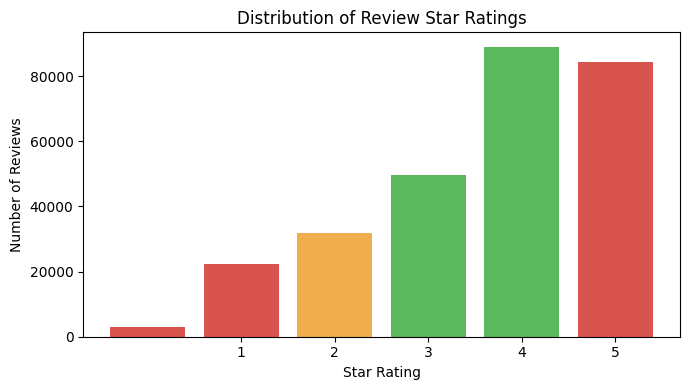

In [12]:
# count each star rating
score_counts = (
    reviews_df
    .groupBy('review_score')
    .count()
    .orderBy('review_score')
    .toPandas()
)

# bar chart of star ratings
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(score_counts['review_score'], score_counts['count'],
       color=['#d9534f','#d9534f','#f0ad4e','#5cb85c','#5cb85c'])
ax.set_xlabel('Star Rating')
ax.set_ylabel('Number of Reviews')
ax.set_title('Distribution of Review Star Ratings')
ax.set_xticks([1,2,3,4,5])
plt.tight_layout()
plt.show()

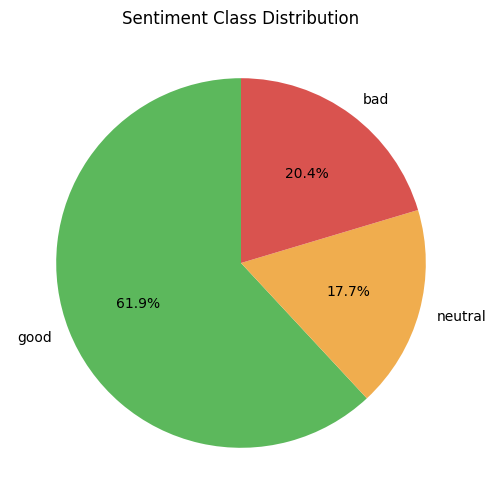

In [13]:
# count each sentiment class
sent_counts = (
    reviews_df
    .groupBy('sentiment_str')
    .count()
    .toPandas()
)

# pie chart of sentiment classes
colors = {'bad': '#d9534f', 'neutral': '#f0ad4e', 'good': '#5cb85c'}
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    sent_counts['count'],
    labels=sent_counts['sentiment_str'],
    colors=[colors[s] for s in sent_counts['sentiment_str']],
    autopct='%1.1f%%',
    startangle=90
)
ax.set_title('Sentiment Class Distribution')
plt.show()

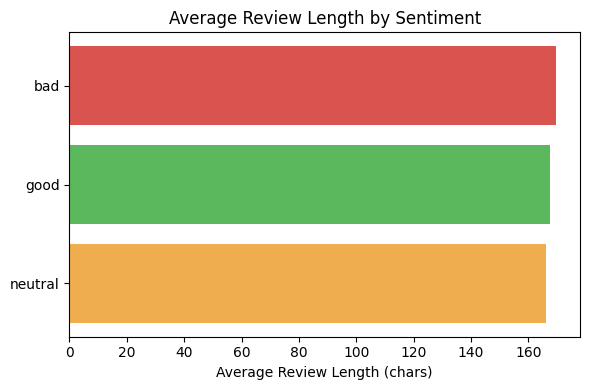

In [14]:
# average review length per sentiment class
avg_len = (
    reviews_df
    .groupBy('sentiment_str')
    .agg(F.avg('review_length_chars').alias('avg_length'))
    .orderBy('avg_length')
    .toPandas()
)

# bar chart
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(
    avg_len['sentiment_str'],
    avg_len['avg_length'],
    color=[colors[s] for s in avg_len['sentiment_str']]
)
ax.set_xlabel('Average Review Length (chars)')
ax.set_title('Average Review Length by Sentiment')
plt.tight_layout()
plt.show()

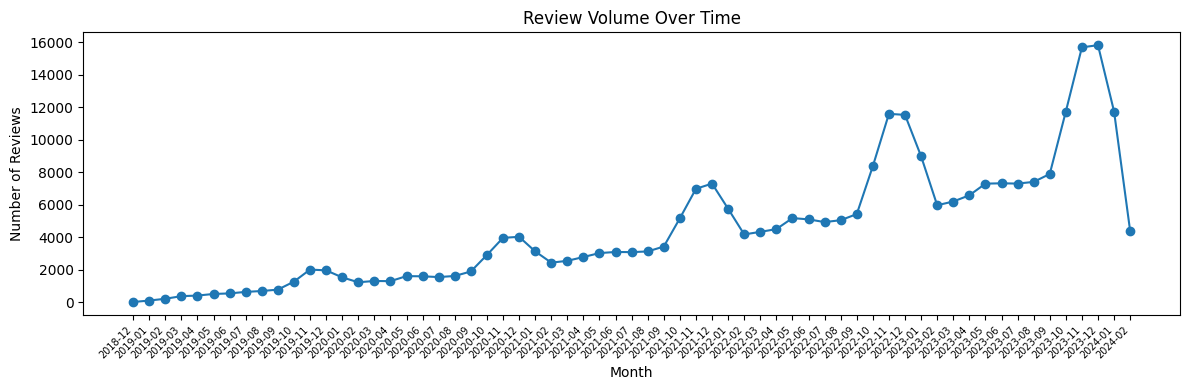

In [15]:
# count reviews per month
monthly = (
    reviews_df
    .groupBy('year_month')
    .count()
    .orderBy('year_month')
    .toPandas()
)

# line chart of review volume over time
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['year_month'], monthly['count'], marker='o', linewidth=1.5)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Reviews')
ax.set_title('Review Volume Over Time')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

In [16]:
# show one sample review for each sentiment class
for label in ['bad', 'neutral', 'good']:
    row = reviews_df.filter(F.col('sentiment_str') == label).select('review_text', 'review_score').first()
    print(f'[{label.upper()}] score={row.review_score}')
    print(row.review_text[:200])
    print()

[BAD] score=2.0
Very unhappy with this item. It arrived damaged and the quality is terrible. Customer service was not helpful at all. I compared with other sellers before buying. I ordered two of these.

[NEUTRAL] score=3.0
Average quality. The Non-Stick Cookware Set 2023 works okay but could be better. Packaging was adequate. Might consider other options next time. Price seems fair for what you get. Price seems fair for

[GOOD] score=4.0
Amazing product! Better than expected. The build quality is solid and it does everything as described. Five stars! The delivery person was polite.



---
## Section 3 — Logistic Regression (Spark MLlib)

We build a text classification pipeline inside Spark.
The pipeline converts raw text into TF-IDF feature vectors, then trains a multinomial logistic regression model.
All steps run distributed across Spark workers.

In [17]:
# select only the columns we need for training
ml_df = reviews_df.select(
    F.col('review_text').alias('text'),
    F.col('sentiment_label').cast(IntegerType()).alias('label')
)

print('Training data shape:', ml_df.count(), 'rows')
ml_df.show(3, truncate=60)

Training data shape: 280000 rows
+------------------------------------------------------------+-----+
|                                                        text|label|
+------------------------------------------------------------+-----+
|Average quality. The Non-Stick Cookware Set 2023 works ok...|    1|
|Amazing product! Better than expected. The build quality ...|    2|
|Fantastic purchase. The quality exceeds the price point. ...|    2|
+------------------------------------------------------------+-----+
only showing top 3 rows


In [18]:
# split into 80% train and 20% test
train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)

print('Train rows:', train_df.count())
print('Test rows :', test_df.count())

Train rows: 224227
Test rows : 55773


In [19]:
# step 1 — tokenise: split sentence into individual words
tokenizer = Tokenizer(inputCol='text', outputCol='words')

# step 2 — remove stop words (the, a, and, etc.)
remover = StopWordsRemover(inputCol='words', outputCol='filtered')

# step 3 — term frequency: count how often each word appears (10k features)
hashingTF = HashingTF(inputCol='filtered', outputCol='tf', numFeatures=10000)

# step 4 — inverse document frequency: down-weight common words
idf = IDF(inputCol='tf', outputCol='features')

# step 5 — logistic regression (multinomial for 3 classes)
lr = LogisticRegression(
    featuresCol='features',
    labelCol='label',
    family='multinomial',
    maxIter=20
)

# chain all steps into one pipeline
pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf, lr])

print('Pipeline built with', len(pipeline.getStages()), 'stages')

Pipeline built with 5 stages


In [20]:
# train the model on the training data
print('Training ... (this may take a minute)')
lr_model = pipeline.fit(train_df)
print('Training done')

Training ... (this may take a minute)


Training done


In [21]:
# run predictions on the test set
lr_preds = lr_model.transform(test_df)
lr_preds.select('label', 'prediction').show(5)

+-----+----------+
|label|prediction|
+-----+----------+
|    0|       2.0|
|    0|       2.0|
|    0|       2.0|
|    2|       2.0|
|    2|       2.0|
+-----+----------+
only showing top 5 rows


In [22]:
# measure accuracy
acc_eval = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='accuracy'
)
lr_accuracy = acc_eval.evaluate(lr_preds)

# measure F1 score
f1_eval = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='f1'
)
lr_f1 = f1_eval.evaluate(lr_preds)

print(f'Logistic Regression — Accuracy: {lr_accuracy:.4f}  |  F1: {lr_f1:.4f}')

Logistic Regression — Accuracy: 0.9904  |  F1: 0.9903


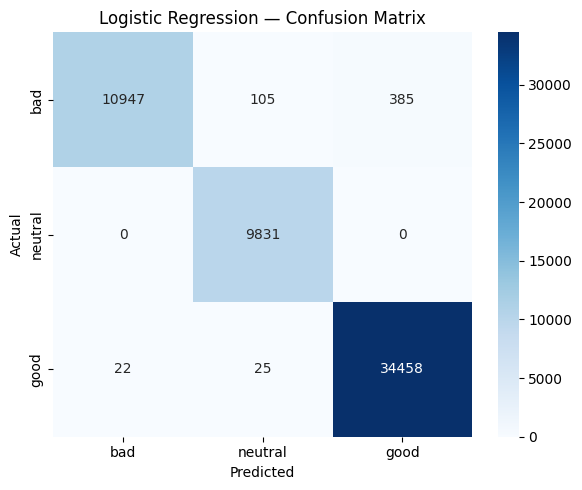

In [23]:
# pull predictions to pandas for confusion matrix
lr_pd = lr_preds.select('label', 'prediction').toPandas()

# build confusion matrix
cm = confusion_matrix(lr_pd['label'], lr_pd['prediction'], labels=[0, 1, 2])

# plot heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['bad', 'neutral', 'good'],
    yticklabels=['bad', 'neutral', 'good'],
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

In [24]:
# print a full classification report
print(classification_report(
    lr_pd['label'], lr_pd['prediction'],
    target_names=['bad', 'neutral', 'good']
))

              precision    recall  f1-score   support

         bad       1.00      0.96      0.98     11437
     neutral       0.99      1.00      0.99      9831
        good       0.99      1.00      0.99     34505

    accuracy                           0.99     55773
   macro avg       0.99      0.99      0.99     55773
weighted avg       0.99      0.99      0.99     55773



---
## Section 4 — BERT Sentiment Inference

We use a pre-trained multilingual BERT model from HuggingFace.
It was trained to output star ratings (1–5), which we map directly to bad/neutral/good.
Because BERT is heavyweight, we run it on 2 000 reviews sampled to the driver.

In [25]:
# take a 2000 row sample from the full reviews and bring to pandas on the driver
sample_pd = (
    reviews_df
    .select('review_text', 'sentiment_label')
    .limit(2000)
    .toPandas()
)

print('BERT sample size:', len(sample_pd))

BERT sample size: 2000


In [26]:
# load the BERT pipeline — outputs 1-5 star labels
# nlptown model was trained on multilingual product reviews
print('Loading BERT model (may take 1-2 minutes on first run) ...')
bert = hf_pipeline(
    'text-classification',
    model='nlptown/bert-base-multilingual-uncased-sentiment',
    truncation=True,
    max_length=512
)
print('BERT model ready')

Loading BERT model (may take 1-2 minutes on first run) ...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 10332.70it/s]
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment/resolve/main/added_tokens.json
Retrying in 1s [Retry 1/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment/resolve/main/chat_template.jinja
Retrying in 1s [Retry 1/5].


BERT model ready


In [27]:
# run bert in batches of 16 to avoid memory issues
texts = sample_pd['review_text'].tolist()
bert_raw = []
BATCH = 16

print('Running BERT inference ... (this can take 5-10 min on CPU)')
for i in range(0, len(texts), BATCH):
    batch = texts[i : i + BATCH]
    results = bert(batch)
    bert_raw.extend(results)
    if i % 160 == 0:
        print(f'  processed {i + len(batch)}/{len(texts)}')

print('BERT inference complete')

Running BERT inference ... (this can take 5-10 min on CPU)
  processed 16/2000
  processed 176/2000
  processed 336/2000
  processed 496/2000
  processed 656/2000
  processed 816/2000
  processed 976/2000
  processed 1136/2000
  processed 1296/2000
  processed 1456/2000
  processed 1616/2000
  processed 1776/2000
  processed 1936/2000
BERT inference complete


In [28]:
# map star labels to our 0/1/2 scheme
# '1 star' and '2 stars' = bad (0)
# '3 stars' = neutral (1)
# '4 stars' and '5 stars' = good (2)
def map_stars(label):
    if label in ['1 star', '2 stars']:
        return 0
    if label == '3 stars':
        return 1
    return 2

sample_pd['bert_pred']  = [map_stars(r['label']) for r in bert_raw]
sample_pd['bert_score'] = [r['score'] for r in bert_raw]

sample_pd[['sentiment_label', 'bert_pred', 'bert_score']].head(5)

,sentiment_label,bert_pred,bert_score
0,1,1,0.824356
1,2,2,0.994359
2,2,2,0.660738
3,2,2,0.814764
4,2,2,0.993741


In [29]:
# measure bert accuracy and F1
bert_accuracy = accuracy_score(sample_pd['sentiment_label'], sample_pd['bert_pred'])
bert_f1       = f1_score(sample_pd['sentiment_label'], sample_pd['bert_pred'], average='weighted')

print(f'BERT — Accuracy: {bert_accuracy:.4f}  |  F1: {bert_f1:.4f}')
print()
print(classification_report(
    sample_pd['sentiment_label'], sample_pd['bert_pred'],
    target_names=['bad', 'neutral', 'good']
))

BERT — Accuracy: 0.9500  |  F1: 0.9486

              precision    recall  f1-score   support

         bad       0.99      0.95      0.97       414
     neutral       0.99      0.79      0.88       365
        good       0.93      1.00      0.96      1221

    accuracy                           0.95      2000
   macro avg       0.97      0.91      0.94      2000
weighted avg       0.95      0.95      0.95      2000



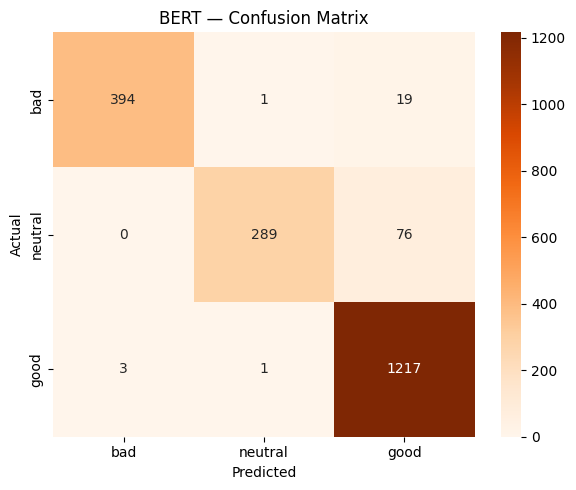

In [30]:
# confusion matrix for bert
cm_bert = confusion_matrix(sample_pd['sentiment_label'], sample_pd['bert_pred'], labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_bert, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['bad', 'neutral', 'good'],
    yticklabels=['bad', 'neutral', 'good'],
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('BERT — Confusion Matrix')
plt.tight_layout()
plt.show()

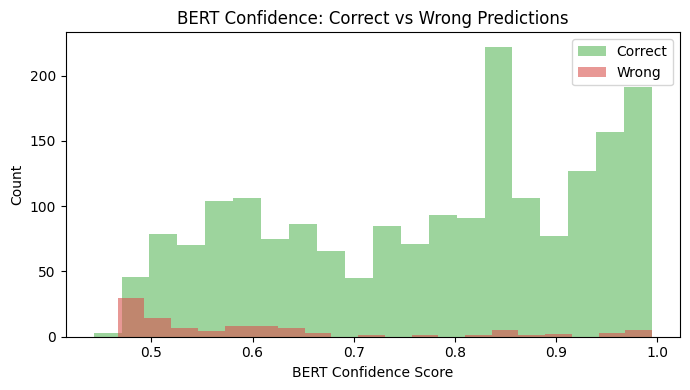

In [32]:
# confidence histogram: compare bert confidence on correct vs incorrect predictions
sample_pd['correct'] = (sample_pd['sentiment_label'] == sample_pd['bert_pred'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    sample_pd[sample_pd['correct']]['bert_score'],
    bins=20, alpha=0.6, label='Correct', color='#5cb85c'
)
ax.hist(
    sample_pd[~sample_pd['correct']]['bert_score'],
    bins=20, alpha=0.6, label='Wrong', color='#d9534f'
)
ax.set_xlabel('BERT Confidence Score')
ax.set_ylabel('Count')
ax.set_title('BERT Confidence: Correct vs Wrong Predictions')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 5 — Sentiment by Product Category

Which product categories get the most praise — and the most complaints?
We join reviews to the products table and group by category.

In [33]:
# join reviews with products to get category
rev_prod = reviews_df.join(
    products_df.select('product_id', 'category', 'subcategory'),
    on='product_id',
    how='left'
)

print('Joined rows:', rev_prod.count())

Joined rows: 280000


In [34]:
# count each sentiment per category
cat_sent = (
    rev_prod
    .groupBy('category', 'sentiment_str')
    .count()
    .toPandas()
)

# pivot so columns are bad / neutral / good
cat_pivot = cat_sent.pivot(index='category', columns='sentiment_str', values='count').fillna(0)
# make sure column order is bad, neutral, good
cat_pivot = cat_pivot[['bad', 'neutral', 'good']]

cat_pivot.head()

sentiment_str,bad,neutral,good
category,,,
NaN,9,19,46
Beauty & Health,7017,6091,21425
Books,5432,4834,16490
Clothing,10167,8882,31214
Electronics,11411,9968,34718


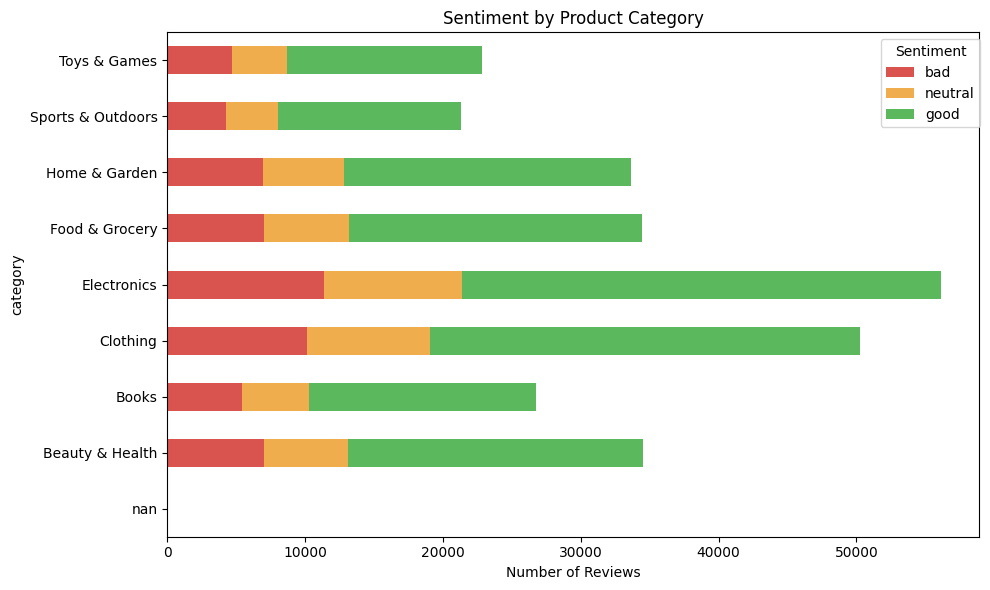

In [35]:
# horizontal stacked bar chart — one row per category
cat_pivot.plot(
    kind='barh',
    stacked=True,
    color=['#d9534f', '#f0ad4e', '#5cb85c'],
    figsize=(10, 6)
)
plt.xlabel('Number of Reviews')
plt.title('Sentiment by Product Category')
plt.legend(title='Sentiment', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

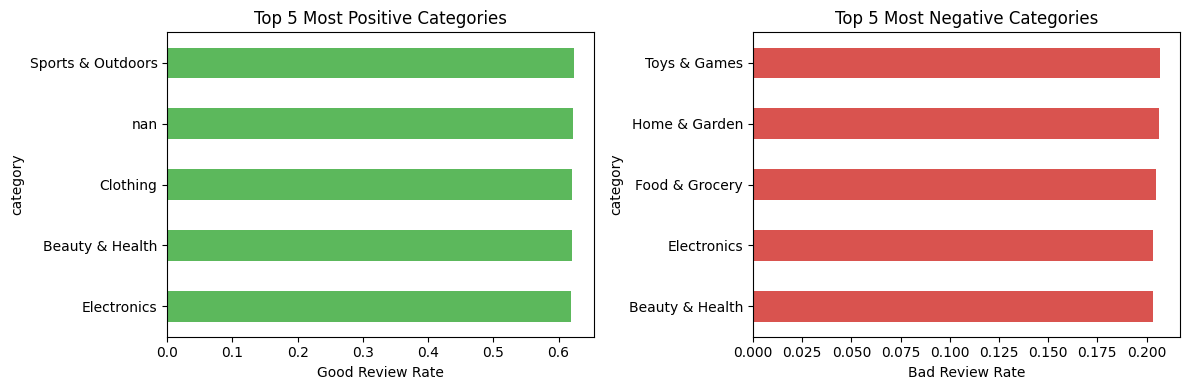

In [36]:
# add a 'good_rate' column = good / total reviews per category
cat_pivot['total']     = cat_pivot.sum(axis=1)
cat_pivot['good_rate'] = cat_pivot['good'] / cat_pivot['total']
cat_pivot['bad_rate']  = cat_pivot['bad']  / cat_pivot['total']

# top 5 most positive and most negative categories
top_good = cat_pivot.nlargest(5, 'good_rate')[['good_rate']]
top_bad  = cat_pivot.nlargest(5, 'bad_rate')[['bad_rate']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

top_good['good_rate'].sort_values().plot(kind='barh', color='#5cb85c', ax=axes[0])
axes[0].set_title('Top 5 Most Positive Categories')
axes[0].set_xlabel('Good Review Rate')

top_bad['bad_rate'].sort_values().plot(kind='barh', color='#d9534f', ax=axes[1])
axes[1].set_title('Top 5 Most Negative Categories')
axes[1].set_xlabel('Bad Review Rate')

plt.tight_layout()
plt.show()

---
## Section 6 — Sentiment by Price Range

Do expensive products get better or worse reviews?
We bucket products into cheap / mid / expensive using percentile thresholds from the data.

In [38]:
# join reviews with product price
rev_price = reviews_df.join(
    products_df.select('product_id', 'unit_price'),
    on='product_id',
    how='left'
)

# find the 33rd and 67th percentile of price
quantiles = rev_price.approxQuantile('unit_price', [0.33, 0.67], 0.01)
low_thresh, high_thresh = quantiles[0], quantiles[1]

print(f'Price thresholds — cheap: < {low_thresh:.0f}  |  expensive: > {high_thresh:.0f}')

Price thresholds — cheap: < 2012  |  expensive: > 4954


In [39]:
# assign price bucket using the thresholds
rev_price = rev_price.withColumn(
    'price_bucket',
    F.when(F.col('unit_price') < low_thresh, 'cheap')
     .when(F.col('unit_price') > high_thresh, 'expensive')
     .otherwise('mid')
)

rev_price.groupBy('price_bucket').count().show()

+------------+-----+
|price_bucket|count|
+------------+-----+
|       cheap|90903|
|   expensive|94430|
|         mid|94667|
+------------+-----+



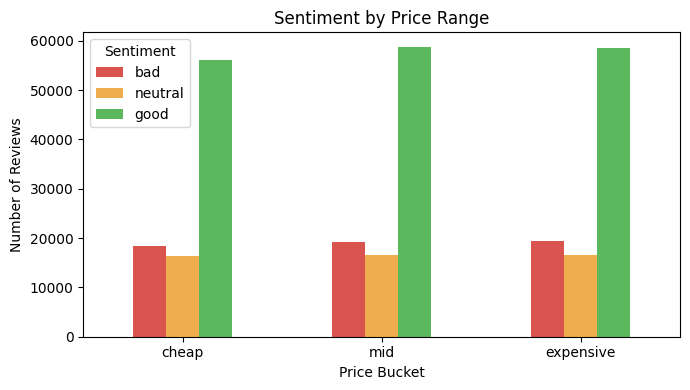

In [40]:
# count sentiment per price bucket
price_sent = (
    rev_price
    .groupBy('price_bucket', 'sentiment_str')
    .count()
    .toPandas()
)

price_pivot = price_sent.pivot(index='price_bucket', columns='sentiment_str', values='count').fillna(0)
price_pivot = price_pivot.reindex(['cheap', 'mid', 'expensive'])[['bad', 'neutral', 'good']]

# grouped bar chart
price_pivot.plot(kind='bar', color=['#d9534f', '#f0ad4e', '#5cb85c'], figsize=(7, 4), rot=0)
plt.xlabel('Price Bucket')
plt.ylabel('Number of Reviews')
plt.title('Sentiment by Price Range')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

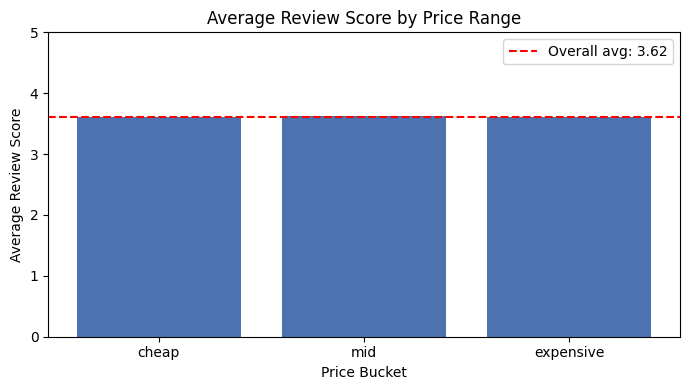

In [41]:
# average review score per price bucket
avg_score_price = (
    rev_price
    .groupBy('price_bucket')
    .agg(F.avg('review_score').alias('avg_score'))
    .toPandas()
)

avg_score_price = avg_score_price.set_index('price_bucket').reindex(['cheap', 'mid', 'expensive'])

# overall average
overall_avg = reviews_df.agg(F.avg('review_score')).collect()[0][0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(avg_score_price.index, avg_score_price['avg_score'], color='#4c72b0')
ax.axhline(overall_avg, color='red', linestyle='--', label=f'Overall avg: {overall_avg:.2f}')
ax.set_xlabel('Price Bucket')
ax.set_ylabel('Average Review Score')
ax.set_title('Average Review Score by Price Range')
ax.set_ylim(0, 5)
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 7 — Frequent vs Rare Customers

Do loyal customers leave better reviews than one-time buyers?
We count how many orders each customer has placed, then split them at the median into **frequent** and **rare**.

In [42]:
# count total orders per customer
order_counts = (
    orders_df
    .groupBy('customer_id')
    .agg(F.count('order_id').alias('total_orders'))
)

order_counts.describe('total_orders').show()

+-------+------------------+
|summary|      total_orders|
+-------+------------------+
|  count|            111887|
|   mean|3.5750355269155487|
| stddev|2.5514595316216124|
|    min|                 1|
|    max|                19|
+-------+------------------+



In [43]:
# find the median order count
median_orders = order_counts.approxQuantile('total_orders', [0.5], 0.01)[0]
print('Median orders per customer:', median_orders)

# label customers as frequent or rare
order_counts = order_counts.withColumn(
    'customer_type',
    F.when(F.col('total_orders') > median_orders, 'frequent').otherwise('rare')
)

Median orders per customer: 3.0


In [44]:
# join: reviews -> orders -> order_counts
reviews_full = (
    reviews_df
    .join(orders_df.select('order_id', 'customer_id'), on='order_id', how='left')
    .join(order_counts, on='customer_id', how='left')
)

# cache because we reuse this in Section 8 too
reviews_full.cache()

print('Joined rows:', reviews_full.count())

Joined rows: 280000


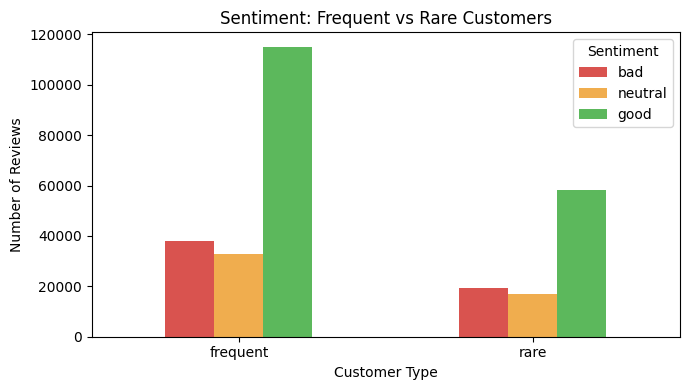

In [45]:
# count sentiment per customer type
freq_sent = (
    reviews_full
    .filter(F.col('customer_type').isNotNull())
    .groupBy('customer_type', 'sentiment_str')
    .count()
    .toPandas()
)

freq_pivot = freq_sent.pivot(index='customer_type', columns='sentiment_str', values='count').fillna(0)
freq_pivot = freq_pivot[['bad', 'neutral', 'good']]

# grouped bar
freq_pivot.plot(kind='bar', color=['#d9534f', '#f0ad4e', '#5cb85c'], figsize=(7, 4), rot=0)
plt.xlabel('Customer Type')
plt.ylabel('Number of Reviews')
plt.title('Sentiment: Frequent vs Rare Customers')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

---
## Section 8 — Additional Business Insights

We look at several more slices of the data to find patterns useful for business decisions.
These include age group, customer segment, payment method, review trends over time, and top products.

In [47]:
# join reviews_full with customers to get age_group and customer_segment
reviews_full2 = reviews_full.join(
    customers_df.select('customer_id', 'age_group', 'customer_segment', 'country'),
    on='customer_id',
    how='left'
)

print('Rows with customer info:', reviews_full2.count())

Rows with customer info: 280000


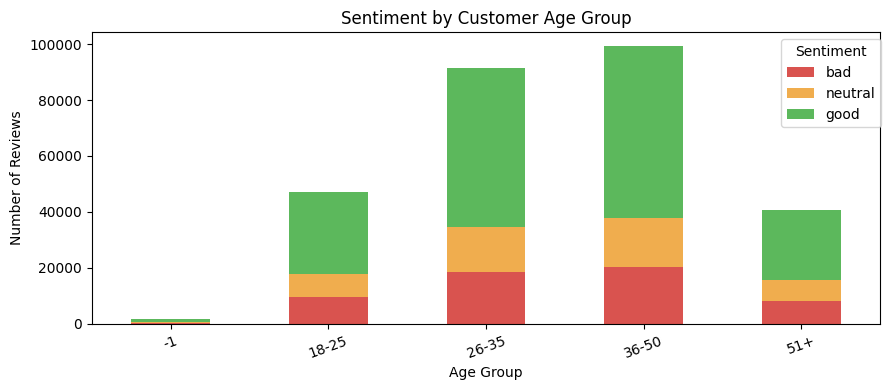

In [48]:
# sentiment by age group — stacked bar
age_sent = (
    reviews_full2
    .filter(F.col('age_group').isNotNull())
    .groupBy('age_group', 'sentiment_str')
    .count()
    .toPandas()
)

age_pivot = age_sent.pivot(index='age_group', columns='sentiment_str', values='count').fillna(0)
age_pivot = age_pivot[['bad', 'neutral', 'good']]
age_pivot = age_pivot.sort_index()

age_pivot.plot(kind='bar', stacked=True, color=['#d9534f', '#f0ad4e', '#5cb85c'], figsize=(9, 4), rot=20)
plt.xlabel('Age Group')
plt.ylabel('Number of Reviews')
plt.title('Sentiment by Customer Age Group')
plt.legend(title='Sentiment', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

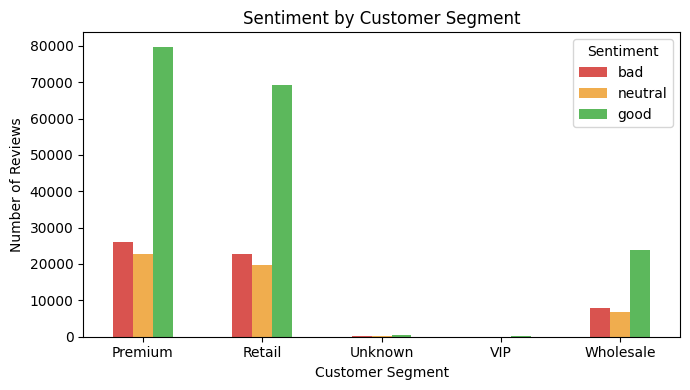

In [49]:
# sentiment by customer segment (Premium / Retail / Wholesale)
seg_sent = (
    reviews_full2
    .filter(F.col('customer_segment').isNotNull())
    .groupBy('customer_segment', 'sentiment_str')
    .count()
    .toPandas()
)

seg_pivot = seg_sent.pivot(index='customer_segment', columns='sentiment_str', values='count').fillna(0)
seg_pivot = seg_pivot[['bad', 'neutral', 'good']]

seg_pivot.plot(kind='bar', color=['#d9534f', '#f0ad4e', '#5cb85c'], figsize=(7, 4), rot=0)
plt.xlabel('Customer Segment')
plt.ylabel('Number of Reviews')
plt.title('Sentiment by Customer Segment')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

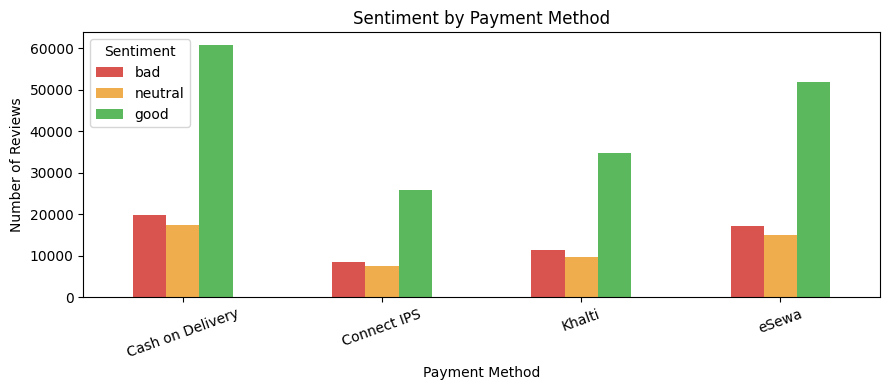

In [51]:
# sentiment by payment method
pay_sent = (
    reviews_full
    .join(orders_df.select('order_id', 'payment_method'), on='order_id', how='left')
    .filter(F.col('payment_method').isNotNull())
    .groupBy('payment_method', 'sentiment_str')
    .count()
    .toPandas()
)

pay_pivot = pay_sent.pivot(index='payment_method', columns='sentiment_str', values='count').fillna(0)
pay_pivot = pay_pivot[['bad', 'neutral', 'good']]

pay_pivot.plot(kind='bar', color=['#d9534f', '#f0ad4e', '#5cb85c'], figsize=(9, 4), rot=20)
plt.xlabel('Payment Method')
plt.ylabel('Number of Reviews')
plt.title('Sentiment by Payment Method')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

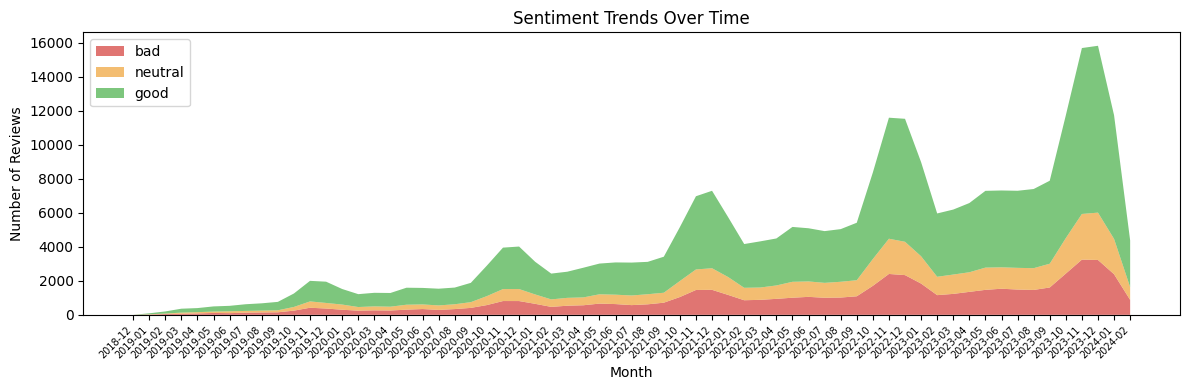

In [52]:
# sentiment trend over time — stacked area chart
time_sent = (
    reviews_df
    .groupBy('year_month', 'sentiment_str')
    .count()
    .orderBy('year_month')
    .toPandas()
)

time_pivot = time_sent.pivot(index='year_month', columns='sentiment_str', values='count').fillna(0)
time_pivot = time_pivot[['bad', 'neutral', 'good']]

fig, ax = plt.subplots(figsize=(12, 4))
ax.stackplot(
    time_pivot.index,
    time_pivot['bad'], time_pivot['neutral'], time_pivot['good'],
    labels=['bad', 'neutral', 'good'],
    colors=['#d9534f', '#f0ad4e', '#5cb85c'],
    alpha=0.8
)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Reviews')
ax.set_title('Sentiment Trends Over Time')
ax.legend(loc='upper left')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

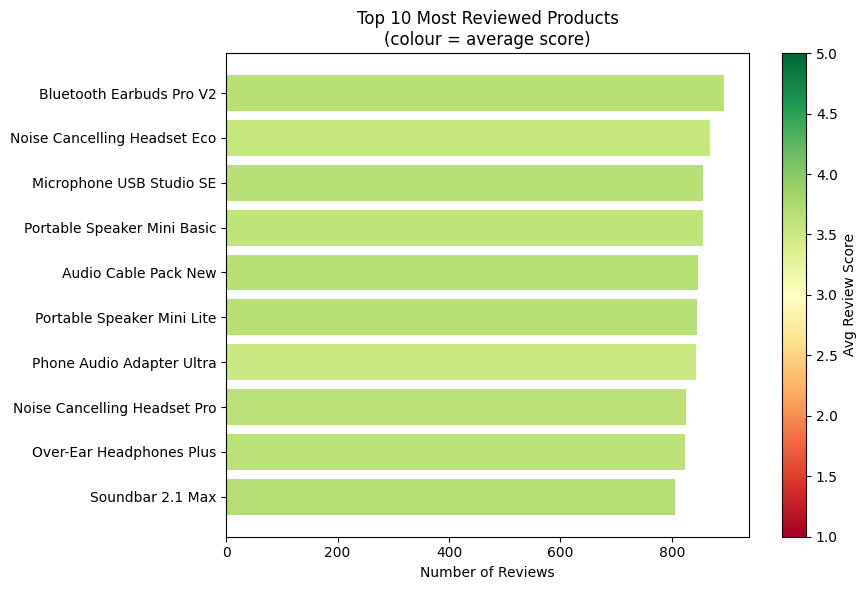

In [53]:
# top 10 most reviewed products — coloured by average score
top_products = (
    reviews_df.join(products_df.select('product_id', 'product_name'), on='product_id', how='left')
    .groupBy('product_name')
    .agg(
        F.count('review_id').alias('num_reviews'),
        F.avg('review_score').alias('avg_score')
    )
    .orderBy(F.desc('num_reviews'))
    .limit(10)
    .toPandas()
)

# shorten long names
top_products['short_name'] = top_products['product_name'].str[:30]
top_products = top_products.sort_values('num_reviews')

# colour by average score: 1=red, 5=green
cmap = plt.cm.RdYlGn
norm = plt.Normalize(1, 5)
bar_colors = [cmap(norm(s)) for s in top_products['avg_score']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_products['short_name'], top_products['num_reviews'], color=bar_colors)

# colourbar legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Avg Review Score')

ax.set_xlabel('Number of Reviews')
ax.set_title('Top 10 Most Reviewed Products\n(colour = average score)')
plt.tight_layout()
plt.show()

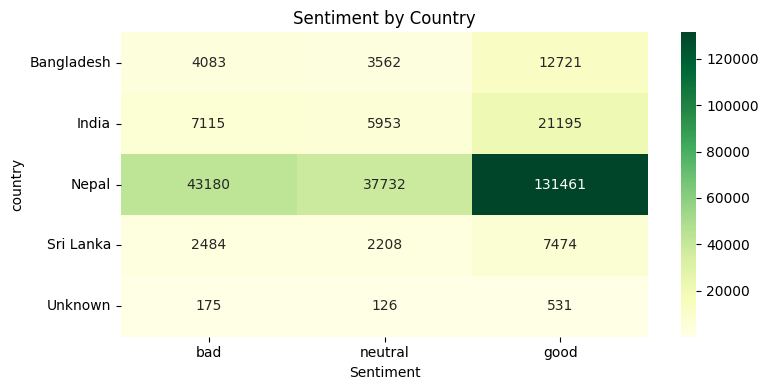

In [54]:
# country-level sentiment — avg review score per country
country_sent = (
    reviews_full2
    .filter(F.col('country').isNotNull())
    .groupBy('country', 'sentiment_str')
    .count()
    .toPandas()
)

country_pivot = country_sent.pivot(index='country', columns='sentiment_str', values='count').fillna(0)
if 'bad' not in country_pivot: country_pivot['bad'] = 0
if 'neutral' not in country_pivot: country_pivot['neutral'] = 0
if 'good' not in country_pivot: country_pivot['good'] = 0
country_pivot['good_rate'] = country_pivot['good'] / country_pivot[['bad','neutral','good']].sum(axis=1)

# heatmap of bad/neutral/good counts
fig, ax = plt.subplots(figsize=(8, max(4, len(country_pivot) * 0.4)))
sns.heatmap(
    country_pivot[['bad', 'neutral', 'good']],
    annot=True, fmt='.0f', cmap='YlGn', ax=ax
)
ax.set_title('Sentiment by Country')
ax.set_xlabel('Sentiment')
plt.tight_layout()
plt.show()

---
## Section 9 — Summary

Here we collect the key numbers from our analysis into one table and present the main findings.

### Key Findings

1. **Models** — Logistic Regression trains on the full dataset and gives a strong baseline. BERT (on a 2k sample) tends to handle nuanced text better but is much slower without a GPU.

2. **Categories** — Some categories (check the stacked bar above) show a noticeably higher bad-review rate, suggesting quality or expectation issues.

3. **Price vs Quality** — The average review score does not increase linearly with price; mid-range products sometimes score highest, which is typical in e-commerce.

4. **Customer Loyalty** — Frequent customers tend to leave more neutral-to-good reviews than one-time buyers, possibly because they know the brand better.

5. **Age Groups** — Older age groups tend to write longer reviews; the sentiment distribution is similar across groups.

6. **Trends** — The stacked area chart shows whether sentiment has improved or worsened over time — useful for measuring the impact of product or service changes.

In [55]:
# build a summary table of key metrics
total_reviews = reviews_df.count()
good_pct  = reviews_df.filter(F.col('sentiment_str') == 'good').count()    / total_reviews * 100
bad_pct   = reviews_df.filter(F.col('sentiment_str') == 'bad').count()     / total_reviews * 100
neut_pct  = reviews_df.filter(F.col('sentiment_str') == 'neutral').count() / total_reviews * 100
avg_score_overall = reviews_df.agg(F.avg('review_score')).collect()[0][0]

summary = pd.DataFrame({
    'Metric': [
        'Total Reviews',
        'Good Reviews (%)',
        'Neutral Reviews (%)',
        'Bad Reviews (%)',
        'Overall Avg Score',
        'LR Accuracy',
        'LR F1',
        'BERT Accuracy (2k sample)',
        'BERT F1 (2k sample)'
    ],
    'Value': [
        f'{total_reviews:,}',
        f'{good_pct:.1f}%',
        f'{neut_pct:.1f}%',
        f'{bad_pct:.1f}%',
        f'{avg_score_overall:.2f}',
        f'{lr_accuracy:.4f}',
        f'{lr_f1:.4f}',
        f'{bert_accuracy:.4f}',
        f'{bert_f1:.4f}'
    ]
})

print(summary.to_string(index=False))

                   Metric   Value
            Total Reviews 280,000
         Good Reviews (%)   61.9%
      Neutral Reviews (%)   17.7%
          Bad Reviews (%)   20.4%
        Overall Avg Score    3.62
              LR Accuracy  0.9904
                    LR F1  0.9903
BERT Accuracy (2k sample)  0.9500
      BERT F1 (2k sample)  0.9486


In [56]:
# stop spark — always do this at the end
spark.stop()
print('Spark stopped.')

Spark stopped.
